# 133.1x: Confined flow with precipitation

## Transient solution (133.16)
This notebook shows the Bruggeman solution for:

One dimensional finite flow. Given head or drawdown at `x=b` and zero flux at `x=0`.

Steady state (133.17) shown as well.

In [1]:
import matplotlib.pyplot as plt
from numpy import linspace

from bruggeman.flow1d import bruggeman_133_16, bruggeman_133_17

In [2]:
bruggeman_133_16

In [3]:
bruggeman_133_16?

Signature:       bruggeman_133_16(*args) -> 'Any'
Type:            LatexifiedFunction
String form:     \begin{array}{l} \beta = \sqrt{ \frac{S}{k D} } \\ \varphi(x, t, b, S, k, D, p, N) = \frac{p}{2 k <...> ht) \pi}{2 \beta b} \mathclose{}\right)^{2} t \mathclose{}\right)}\mathclose{}\right) \end{array}
File:            ~/github/bruggeman/.venv/lib/python3.13/site-packages/latexify/ipython_wrappers.py
Docstring:      
Confined aquifer with zero head at x=b, zero flux at x=0
and a constant arbitrary precipitation p.

From Bruggeman 133.16

Parameters
----------
x : float or ndarray
    Distance from the boundary [m]
t : float or ndarray
    Time [d]
b : float
    Half width of the aquifer [m]
S : float
    Storage coefficient [-]
k : float
    Hydraulic conductivity [m/d]
D : float
    Aquifer thickness [m]
p : float
    Arbitrary constant precipitation [m/d]
N : int
    Number of terms in the series expansion to approximate the infinite sum,
    by default 10 [-]

Returns
-------
head 

## Transient graph

In [4]:
# aquifer parameters
b = 100.0 / 2
S = 0.1
k = 10.0
D = 5.0
p = 1e-3  # constant precipitation flux

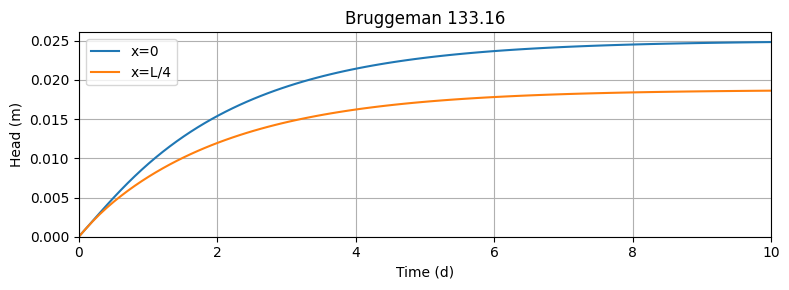

In [5]:
t = linspace(0.0, 10.0, 100)
hx0 = bruggeman_133_16(0.0, t, b, S, k, D, p)
hxb2 = bruggeman_133_16(b / 2, t, b, S, k, D, p)

plt.figure(figsize=(8, 3), layout="tight")
plt.plot(t, hx0, label="x=0")
plt.plot(t, hxb2, label="x=L/4")

plt.grid(True)
plt.xlabel("Time (d)")
plt.ylabel("Head (m)")
plt.title("Bruggeman 133.16")
plt.xlim(t[0], t[-1])
plt.ylim(0.0)
plt.legend();

## Steady state solution (133.17)

In [6]:
bruggeman_133_17

In [7]:
bruggeman_133_17?

Signature:       bruggeman_133_17(*args) -> 'Any'
Type:            LatexifiedFunction
String form:     \varphi(x, b, k, D, p) = \frac{p}{2 k D} \cdot \mathopen{}\left( b^{2} - x^{2} \mathclose{}\right)
File:            ~/github/bruggeman/.venv/lib/python3.13/site-packages/latexify/ipython_wrappers.py
Docstring:      
Confined aquifer with zero head at x=b, zero flux at x=0
and a constant arbitrary precipitation p. Steady state.

From Bruggeman 133.17

Parameters
----------
x : float or ndarray
    Distance from the boundary [m]
b : float
    Half width of the aquifer [m]
k : float
    Hydraulic conductivity [m/d]
D : float
    Aquifer thickness [m]
p : float
    Arbitrary constant precipitation [m/d]

Returns
-------
head : float
    Head in the aquifer at distance x [m]
Class docstring: Function with latex representation.

## Drainage to canals

This equation can be used to model drainage to drains and canals. 

Results are equal to Krayenhoff van de Leur - Maasland (e.g.: 'Cultuurtechnisch Vademecum', 1988, page 523).

In [11]:
import ttim
import numpy as np

mlconf = ttim.ModelXsection(naq=1, tmin=1e-3, tmax=1e3)

left = ttim.XsectionMaq(
    mlconf,
    -np.inf,
    -b,
    kaq=k,
    z=[0, -D],
    Saq=S,
    topboundary="conf",
    phreatictop=True,
)
inf = ttim.XsectionMaq(
    mlconf,
    -b,
    b,
    kaq=k,
    z=[0, -D],
    Saq=S,
    # c=c,
    topboundary="conf",
    phreatictop=True,
    tsandN=[(0.0, p)],
)
right = ttim.XsectionMaq(
    mlconf,
    b,
    np.inf,
    kaq=k,
    z=[0, -D],
    Saq=S,
    # c=c,
    topboundary="conf",
    phreatictop=True,
)

d = -1e-3
hls_left = ttim.HeadLineSink1D(mlconf, xls=-b + d, tsandh=[(0, 0.0)], layers=[0])
hls_right = ttim.HeadLineSink1D(mlconf, xls=b - d, tsandh=[(0, 0.0)], layers=[0])

mlconf.solve()

self.neq  6
solution complete


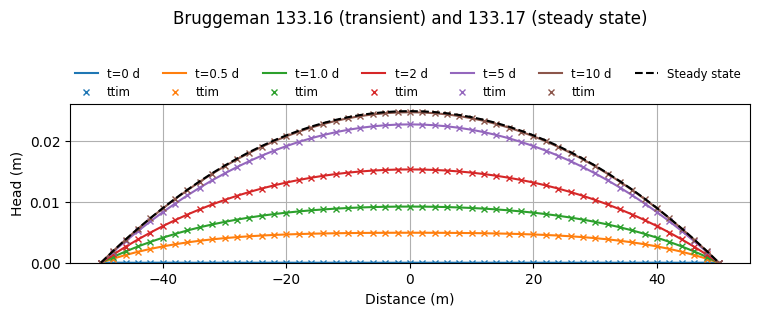

In [18]:
x = linspace(-b, b, 51)
t_steps = [0, 0.5, 1.0, 2, 5, 10]  # time steps in days

fig, ax = plt.subplots(figsize=(8, 3), layout="tight")
for t in t_steps:
    ht = bruggeman_133_16(x, t, b, S, k, D, p)
    p0,  = ax.plot(x, ht, label=f"t={t} d")
    ax.plot(
        x,
        mlconf.headalongline(x, np.zeros_like(x), t)[0, 0],
        label="ttim",
        marker="x",
        linestyle="none",
        markersize=4,
        color=p0.get_color(),
    )

h_ss = bruggeman_133_17(x, b, k, D, p)
ax.plot(x, h_ss, label="Steady state", color="k", linestyle="--")

ax.grid(True)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Head (m)")
ax.set_title("Bruggeman 133.16 (transient) and 133.17 (steady state)", y=1.45)
ax.set_ylim(0.0)
ax.legend(loc=(0, 1), ncol=7, fontsize="small", frameon=False);